In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("C:/Users/Geli/Desktop/climate-challenge-week0/data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000


In [5]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [6]:
df = df.replace(-999, np.nan)

In [7]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,2015-01-05,1


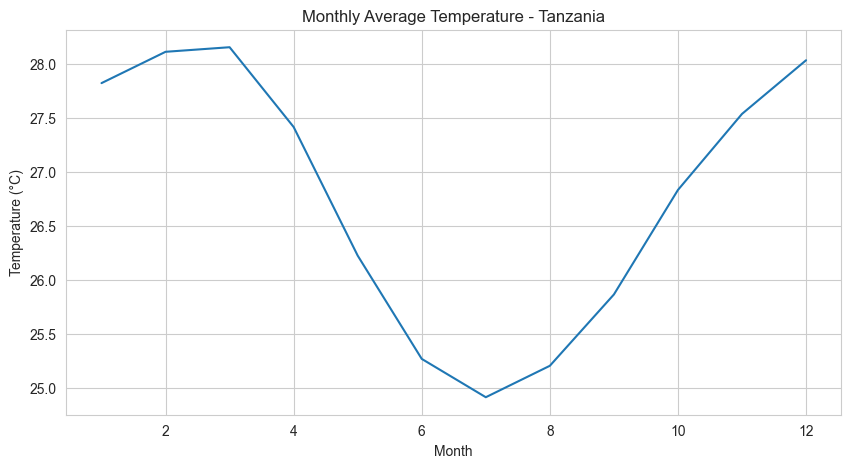

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(figsize=(10,5))
plt.title("Monthly Average Temperature - Tanzania")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

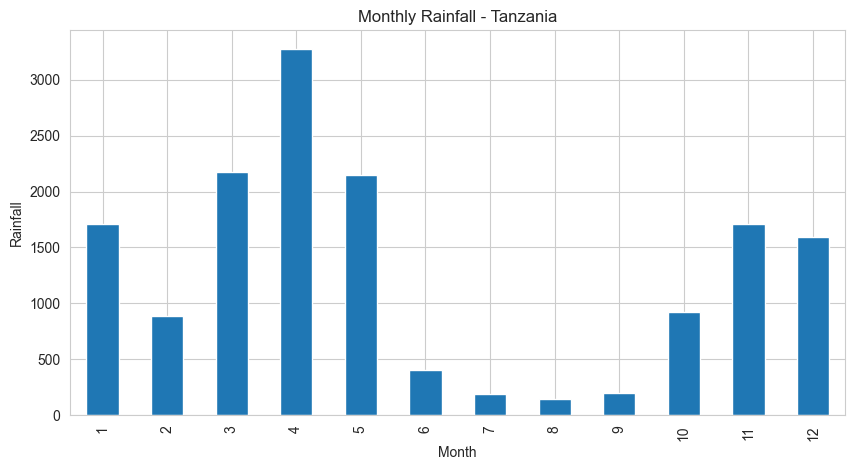

In [9]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Rainfall - Tanzania")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

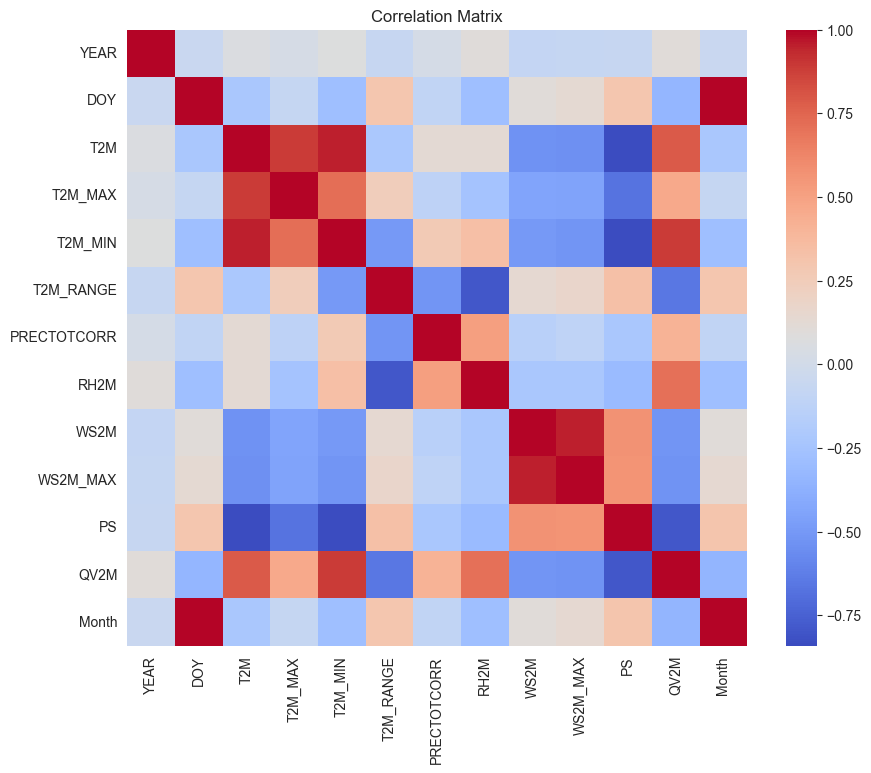

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

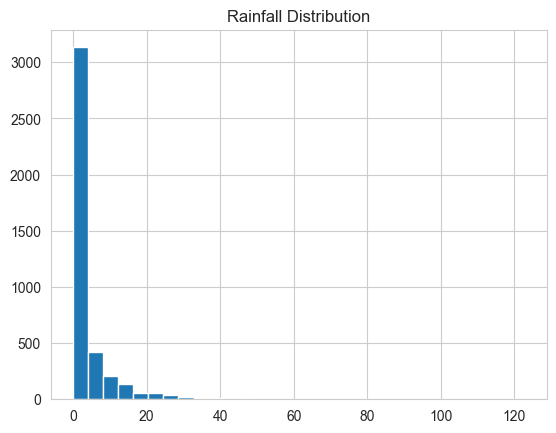

In [11]:
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.title("Rainfall Distribution")
plt.show()

## Temperature Analysis
- Temperature shows seasonal variation
- Rainfall is concentrated in certain months
- Weak/strong correlations between variables